# Основы вероятности

## Модуль 1: Фундаментальные понятия теории вероятностей

В этом ноутбуке мы рассмотрим базовые концепции теории вероятностей, которые необходимы для понимания статистики и машинного обучения.

### Содержание:
1. Пространство исходов и события
2. Аксиомы вероятности
3. Условная вероятность
4. Теорема Байеса
5. Независимость и взаимоисключаемость

## 1. Пространство исходов и события

**Определение:** Пространство исходов (样本空间) $\Omega$ — это множество всех возможных результатов случайного эксперимента.

**Примеры:**
- Бросок монеты: $\Omega = \{H, T\}$ (орёл, решка)
- Бросок кубика: $\Omega = \{1, 2, 3, 4, 5, 6\}$
- Измерение температуры: $\Omega = [35, 42]$ (в градусах Цельсия)

**Событие** $A$ — это подмножество пространства исходов: $A \subseteq \Omega$

**Примеры событий:**
- $A$ = "выбросить чётное число" = $\{2, 4, 6\}$
- $B$ = "выбросить число больше 4" = $\{5, 6\}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Пример: Пространство исходов при броске двух кубиков
outcomes = list(product(range(1, 7), repeat=2))
print(f'Пространство исходов при броске двух кубиков:')
print(f'Количество элементов: {len(outcomes)}')
print(f'Примеры исходов: {outcomes[:5]}...')

Пространство исходов при броске двух кубиков:
Количество элементов: 36
Примеры исходов: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5)]...


## 2. Аксиомы вероятности

Теория вероятностей основана на трёх аксиомах, сформулированных А.Н. Колмогоровым:

**Аксиома 1 (Неотрицательность):** Для любого события $A$
$$P(A) \geq 0$$

**Аксиома 2 (Нормировка):** Вероятность достоверного события равна 1:
$$P(\Omega) = 1$$

**Аксиома 3 (Счётная аддитивность):** Для любой последовательности попарно несовместных событий $A_1, A_2, ...$
$$P\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} P(A_i)$$

**Следствия из аксиом:**
- $P(\emptyset) = 0$ (вероятность невозможного события)
- $P(A^c) = 1 - P(A)$ (вероятность дополнения)
- Если $A \subseteq B$, то $P(A) \leq P(B)$

In [1]:
# Демонстрация аксиом на примере броска кубика
# Пространство исходов
omega = {1, 2, 3, 4, 5, 6}

# Событие A: выпало чётное число
A = {2, 4, 6}

# Событие B: выпало число больше 3
B = {4, 5, 6}

# Вычисление вероятностей (классическое определение)
P_A = len(A) / len(omega)
P_B = len(B) / len(omega)

print(f'P(A) = P(чётное) = {P_A:.2f}')
print(f'P(B) = P(>3) = {P_B:.2f}')
print(f'P(Ω) = {len(omega)/len(omega):.2f}')  # Нормировка
print(f'P(A^c) = 1 - P(A) = {1 - P_A:.2f}')  # Дополнение

P(A) = P(чётное) = 0.50
P(B) = P(>3) = 0.50
P(Ω) = 1.00
P(A^c) = 1 - P(A) = 0.50


## 3. Условная вероятность

**Определение:** Условная вероятность события $A$ при условии наступления события $B$ ($P(B) > 0$):

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

**Интуитивное понимание:** Вероятность $A$ в "сокращённом" пространстве, где уже известно, что $B$ произошло.

**Формула полной вероятности:**
Если $B_1, B_2, ..., B_n$ — полная группа событий, то
$$P(A) = \sum_{i=1}^{n} P(A|B_i) P(B_i)$$

In [2]:
# Пример: Условная вероятность
# Урна с 3 белыми и 2 чёрными шарами
# Достаём 2 шара без возврата

# Пространство исходов
urn = ['W1', 'W2', 'W3', 'B1', 'B2']  # W - белый, B - чёрный

# Все возможные комбинации 2 шаров
from itertools import combinations

all_pairs = list(combinations(urn, 2))
print(f'Все возможные пары шаров ({len(all_pairs)}):')
for pair in all_pairs[:5]:
    print(f'  {pair}')
print('  ...')

# Событие A: оба шара белые
A = [pair for pair in all_pairs if pair[0][0] == 'W' and pair[1][0] == 'W']
print(f'\nПары с двумя белыми шарами: {A}')

# Событие B: первый шар белый
B = [pair for pair in all_pairs if pair[0][0] == 'W']
print(f'Пары, где первый шар белый: {len(B)}')

# Условная вероятность P(A|B)
P_A_and_B = len([p for p in A if p in B]) / len(all_pairs)
P_B = len(B) / len(all_pairs)
P_A_given_B = P_A_and_B / P_B

print(f'\nP(A ∩ B) = {P_A_and_B:.4f}')
print(f'P(B) = {P_B:.4f}')
print(f'P(A|B) = P(A ∩ B) / P(B) = {P_A_given_B:.4f}')

Все возможные пары шаров (10):
  ('W1', 'W2')
  ('W1', 'W3')
  ('W1', 'B1')
  ('W1', 'B2')
  ('W2', 'W3')
  ...

Пары с двумя белыми шарами: [('W1', 'W2'), ('W1', 'W3'), ('W2', 'W3')]
Пары, где первый шар белый: 9

P(A ∩ B) = 0.3000
P(B) = 0.9000
P(A|B) = P(A ∩ B) / P(B) = 0.3333


## 4. Теорема Байеса

**Теорема Байеса** связывает условные вероятности события и его дополнения:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Или в более общей форме:

$$P(A_i|B) = \frac{P(B|A_i) \cdot P(A_i)}{\sum_{j=1}^{n} P(B|A_j) \cdot P(A_j)}$$

**Компоненты:**
- $P(A)$ — априорная вероятность (prior)
- $P(B|A)$ — правдоподобие (likelihood)
- $P(A|B)$ — апостериорная вероятность (posterior)
- $P(B)$ — нормализующая константа (evidence)

**Пример из медицины:** Тест на заболевание

In [3]:
# Пример: Теорема Байеса для медицинского теста
# Заболевание встречается с вероятностью 1%
# Тест имеет точность 95% (чувствительность и специфичность)

# Априорные вероятности
P_disease = 0.01      # P(Заболевание)
P_healthy = 0.99      # P(Здоров)

# Характеристики теста
P_pos_given_disease = 0.95   # P(Тест+|Заболевание) - чувствительность
P_neg_given_healthy = 0.95   # P(Тест-|Здоров) - специфичность
P_pos_given_healthy = 1 - P_neg_given_healthy  # P(Тест+|Здоров)

# Полная вероятность положительного теста
P_positive = (P_pos_given_disease * P_disease + 
              P_pos_given_healthy * P_healthy)

# Теорема Байеса: P(Заболевание|Тест+)
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_positive

print('Пример: Медицинский тест')
print('=' * 50)
print(f'Вероятность заболевания: {P_disease:.2%}')
print(f'Чувствительность теста: {P_pos_given_disease:.2%}')
print(f'Специфичность теста: {P_neg_given_healthy:.2%}')
print('=' * 50)
print(f'P(Тест+) = {P_positive:.4f}')
print(f'P(Заболевание|Тест+) = {P_disease_given_pos:.4f}')
print(f'\nВывод: Даже при положительном тесте вероятность')
print(f'заболевания всего {P_disease_given_pos:.2%}!')

Пример: Медицинский тест
Вероятность заболевания: 1.00%
Чувствительность теста: 95.00%
Специфичность теста: 95.00%
P(Тест+) = 0.0590
P(Заболевание|Тест+) = 0.1610

Вывод: Даже при положительном тесте вероятность
заболевания всего 16.10%!


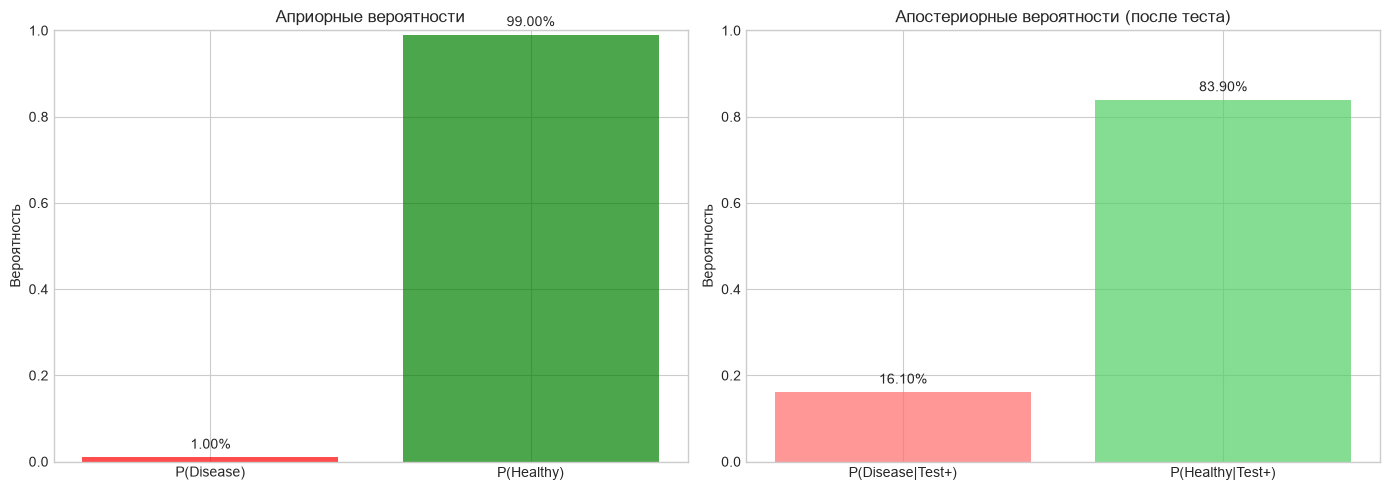

In [4]:
# Визуализация теоремы Байеса
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Диаграмма вероятностей
categories = ['P(Disease)', 'P(Healthy)']
priors = [P_disease, P_healthy]
axes[0].bar(categories, priors, color=['red', 'green'], alpha=0.7)
axes[0].set_ylabel('Вероятность')
axes[0].set_title('Априорные вероятности')
axes[0].set_ylim(0, 1)
for i, v in enumerate(priors):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center')

# Обновление вероятностей после теста
posterior_categories = ['P(Disease|Test+)', 'P(Healthy|Test+)']
posteriors = [P_disease_given_pos, 1 - P_disease_given_pos]
colors_post = ['#ff6b6b', '#51cf66']
axes[1].bar(posterior_categories, posteriors, color=colors_post, alpha=0.7)
axes[1].set_ylabel('Вероятность')
axes[1].set_title('Апостериорные вероятности (после теста)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(posteriors):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.show()

## 5. Независимость и взаимоисключаемость

### Независимые события
**Определение:** События $A$ и $B$ **независимы**, если:
$$P(A \cap B) = P(A) \cdot P(B)$$

Эквивалентно: $P(A|B) = P(A)$ (знание о $B$ не меняет вероятность $A$)

### Взаимоисключаемые события
**Определение:** События $A$ и $B$ **взаимоисключаемы** (несовместны), если:
$$P(A \cap B) = 0$$

Это означает, что события не могут произойти одновременно.

**Важно:** Взаимоисключаемые события **не могут быть независимими** (если $P(A), P(B) > 0$).

In [5]:
# Демонстрация независимости и взаимоисключаемости

# Пример 1: Независимые события
# Бросок монеты и кубика
P_heads = 0.5    # P(орёл)
P_six = 1/6      # P(6 на кубике)

# Независимые: P(орёл и 6) = P(орёл) * P(6)
P_heads_and_six = P_heads * P_six
print('Пример 1: Независимые события')
print(f'P(орёл) = {P_heads:.4f}')
print(f'P(6) = {P_six:.4f}')
print(f'P(орёл ∩ 6) = {P_heads_and_six:.4f}')
print(f'P(орёл) * P(6) = {P_heads * P_six:.4f}')
print(f'Независимы? {np.isclose(P_heads_and_six, P_heads * P_six)}')

print('\n' + '='*50)

# Пример 2: Взаимоисключаемые события
# Бросок кубика: чётное или нечётное
P_even = 3/6     # P(чётное) = {2, 4, 6}
P_odd = 3/6      # P(нечётное) = {1, 3, 5}
P_even_and_odd = 0  # Не могут быть одновременно

print('\nПример 2: Взаимоисключаемые события')
print(f'P(чётное) = {P_even:.4f}')
print(f'P(нечётное) = {P_odd:.4f}')
print(f'P(чётное ∩ нечётное) = {P_even_and_odd}')
print(f'P(чётное) * P(нечётное) = {P_even * P_odd:.4f}')
print(f'Взаимоисключаемы? {P_even_and_odd == 0}')
print(f'Независимы? {np.isclose(P_even_and_odd, P_even * P_odd)}')

Пример 1: Независимые события
P(орёл) = 0.5000
P(6) = 0.1667
P(орёл ∩ 6) = 0.0833
P(орёл) * P(6) = 0.0833
Независимы? True


Пример 2: Взаимоисключаемые события
P(чётное) = 0.5000
P(нечётное) = 0.5000
P(чётное ∩ нечётное) = 0
P(чётное) * P(нечётное) = 0.2500
Взаимоисключаемы? True
Независимы? False


/var/folders/z9/s38n2c3115q8ndnpnv3nm6rm0000gn/T/ipykernel_1436/3231598492.py:34: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  plt.tight_layout()
/Users/timko/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


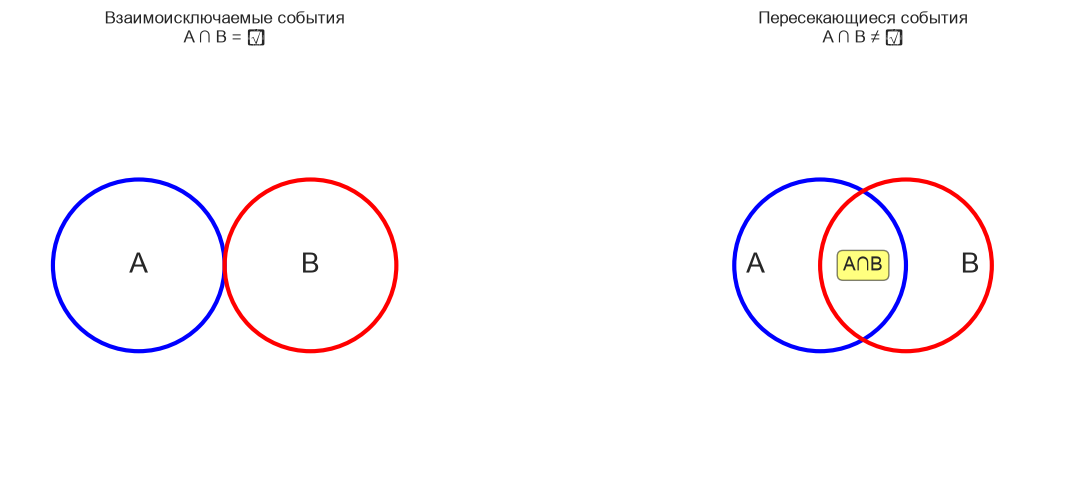

In [6]:
# Визуализация: Взаимоисключаемые vs Пересекающиеся события
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Взаимоисключаемые события
from matplotlib.patches import Circle

circle1 = Circle((0.3, 0.5), 0.2, fill=False, edgecolor='blue', linewidth=3)
circle2 = Circle((0.7, 0.5), 0.2, fill=False, edgecolor='red', linewidth=3)
axes[0].add_patch(circle1)
axes[0].add_patch(circle2)
axes[0].text(0.3, 0.5, 'A', ha='center', va='center', fontsize=20)
axes[0].text(0.7, 0.5, 'B', ha='center', va='center', fontsize=20)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect('equal')
axes[0].set_title('Взаимоисключаемые события\nA ∩ B = ∅')
axes[0].axis('off')

# Пересекающиеся события
circle3 = Circle((0.4, 0.5), 0.2, fill=False, edgecolor='blue', linewidth=3)
circle4 = Circle((0.6, 0.5), 0.2, fill=False, edgecolor='red', linewidth=3)
axes[1].add_patch(circle3)
axes[1].add_patch(circle4)
axes[1].text(0.25, 0.5, 'A', ha='center', va='center', fontsize=20)
axes[1].text(0.75, 0.5, 'B', ha='center', va='center', fontsize=20)
axes[1].text(0.5, 0.5, 'A∩B', ha='center', va='center', fontsize=14, 
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect('equal')
axes[1].set_title('Пересекающиеся события\nA ∩ B ≠ ∅')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Упражнения

### Упражнение 1: Бросок двух кубиков
При броске двух кубиков вычислите:
1. Вероятность суммы 7
2. Вероятность суммы 7 при условии, что первый кубик показал 3
3. Являются ли события "первый кубик = 3" и "сумма = 7" независимыми?

### Упражнение 2: Диагностика болезни
Заболевание встречается у 2% населения. Тест имеет:
- Чувствительность 90% (P(Test+|Disease))
- Специфичность 95% (P(Test-|Healthy))

Вычислите:
1. P(Test+)
2. P(Disease|Test+)
3. Как изменится результат, если заболеваемость составит 20%?

### Упражнение 3: Урна с шарами
В урне 5 белых и 3 чёрных шара. Достаём 2 шара без возврата.
1. Какова вероятность, что оба шара белые?
2. Какова вероятность, что второй шар белый при условии, что первый был белый?

### Упражнение 4: Независимость событий
Проверьте, являются ли события независимыми:
- $P(A) = 0.3$, $P(B) = 0.4$, $P(A \cap B) = 0.12$
- $P(A) = 0.5$, $P(B) = 0.5$, $P(A \cap B) = 0.3$

---

**Решения** можно найти в ноутбуке `solutions/01_Solutions.ipynb`